# Disease Prediction Evaluation Dashboard

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("healthcare_disease_prediction_2000.csv")
df.head()

,Patient_ID,Age,Gender,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol,Glucose_Level,Smoking,Alcohol_Intake,Physical_Activity,Family_History,Heart_Disease,Diabetes,Stroke
0,1,69,Male,34.1,127,71,184,154,1,1,0,0,0,1,0
1,2,32,Male,25.0,148,69,177,136,1,1,1,0,0,0,0
2,3,78,Male,25.2,98,93,252,110,0,0,0,0,0,0,0
3,4,38,Male,9.6,162,102,274,87,1,0,1,0,0,0,0
4,5,41,Female,29.0,161,69,251,127,0,1,1,0,0,0,0


In [3]:
df.isnull().sum()

Patient_ID                  0
Age                         0
Gender                      0
BMI                         0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Cholesterol                 0
Glucose_Level               0
Smoking                     0
Alcohol_Intake              0
Physical_Activity           0
Family_History              0
Heart_Disease               0
Diabetes                    0
Stroke                      0
dtype: int64

In [4]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Cholesterol', 'Glucose_Level', 'Smoking',
       'Alcohol_Intake', 'Physical_Activity', 'Family_History',
       'Heart_Disease', 'Diabetes', 'Stroke'],
      dtype='str')

In [5]:
df.shape

(2000, 15)

In [6]:
X = df[["Age","BMI", "Blood_Pressure_Systolic",
       "Blood_Pressure_Diastolic", "Cholesterol", "Glucose_Level", "Smoking",
       "Alcohol_Intake", "Physical_Activity", "Family_History"]]

y = df["Heart_Disease"]

In [7]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    random_state = 42,
    test_size = 0.2
)

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)*100

print("Accuracy:", accuracy)

Accuracy: 97.0


In [11]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)*100

print("Precision:", precision)

Precision: 86.95652173913044


In [12]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)*100

print("Recall:", recall)

Recall: 68.96551724137932


In [13]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)*100

print("F1 Score:", f1)

F1 Score: 76.92307692307693


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[368   3]
 [  9  20]]


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       371
           1       0.87      0.69      0.77        29

    accuracy                           0.97       400
   macro avg       0.92      0.84      0.88       400
weighted avg       0.97      0.97      0.97       400



In [16]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, y_prob)*100

print("ROC-AUC:", roc)

ROC-AUC: 98.49428385537689


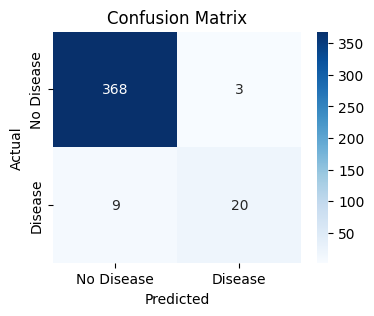

In [17]:
plt.figure(figsize=(4,3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

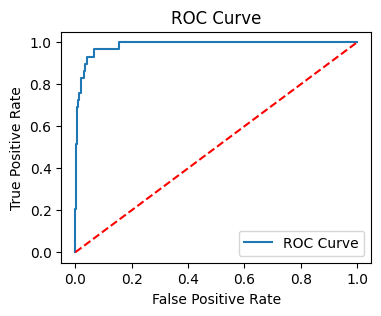

In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(4,3))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [19]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


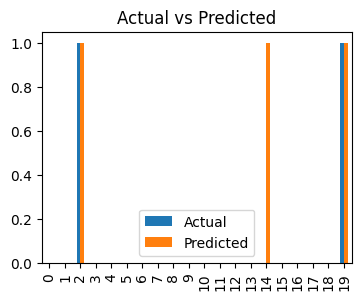

In [20]:
comparison.head(20).plot(kind="bar", figsize=(4,3))

plt.title("Actual vs Predicted")
plt.show()

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(importance)

                    Feature  Coefficient
0                       Age     0.134893
2   Blood_Pressure_Systolic     0.107907
8         Physical_Activity     0.103502
4               Cholesterol     0.073851
3  Blood_Pressure_Diastolic     0.006290
5             Glucose_Level    -0.001115
1                       BMI    -0.041059
6                   Smoking    -0.083451
9            Family_History    -0.184516
7            Alcohol_Intake    -0.321321
